In [71]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import warnings
import statsmodels.api as sm

In [72]:
#HAR Config
class Config:
    initial_train_years: int = 4
    test_months: int = 1
    target_col: str = "RV_daily"
    lags: tuple = (1, 5, 22) #standard lag when BIC is false
    add_constant: bool = True #for OLS

    #BIC config
    use_bic: bool
    weekly_candidates: tuple = (5, 16, 22, 32, 44, 66, 88)
    monthly_candidates: tuple = (16, 22, 44, 66, 88)

In [73]:
# Data parsing
def load_and_prepare_data(filepath):
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"
    rv.sort_index(inplace=True)

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min().date()} to {rv.index.max().date()}")
    return rv

In [74]:
# Creating HAR lags and OLS fitting
def create_har_lags(
    df: pd.DataFrame,
    target_col: str = "RV_daily",
    lags=(1, 5, 22),
    use_bic: bool = False,
    train_start: pd.Timestamp = None,
    train_end: pd.Timestamp = None,
    candidate_week_lags = Config.weekly_candidates,
    candidate_month_lags = Config.monthly_candidates,
    add_constant: bool = True,
    return_selected: bool = False
):
    out = df.copy().sort_index()
    if not isinstance(out.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex.")

    d1, d5, d22 = lags

    # HAR(1,5,22)
    if not use_bic:
        out["RV_lag1"]  = out[target_col].shift(d1)
        out["RV_lag5"]  = out[target_col].rolling(window=d5).mean().shift(1)
        out["RV_lag22"] = out[target_col].rolling(window=d22).mean().shift(1)
        out = out.dropna(subset=["RV_lag1", "RV_lag5", "RV_lag22"]).copy()
        return (out, d5, d22) if return_selected else out

    # BIC over both weekly and monthly windows
    best = (None, None)
    best_bic = np.inf

    def build_lags(Lw, Lm):
        tmp = out.copy()
        tmp["RV_lag1"]  = tmp[target_col].shift(d1)
        tmp["RV_lag5"]  = tmp[target_col].rolling(window=Lw).mean().shift(1)    # name kept
        tmp["RV_lag22"] = tmp[target_col].rolling(window=Lm).mean().shift(1)    # name kept
        return tmp.dropna(subset=["RV_lag1", "RV_lag5", "RV_lag22"]).copy()

    for Lw in candidate_week_lags:
        for Lm in candidate_month_lags:
            dfL = build_lags(Lw, Lm)
            train_df = dfL.loc[train_start:train_end]

            # Avoid exact multicollinearity (e.g., Lw==1 duplicates lag1, or Lw==Lm)
            X = train_df[["RV_lag1", "RV_lag5", "RV_lag22"]].values
            if add_constant:
                X = np.column_stack([np.ones(len(train_df)), X])
            if np.linalg.matrix_rank(X) < X.shape[1]:
                continue

            _, model, _ = fit_har_ols(train_df, target_col=target_col, add_constant=add_constant)
            bic_val = float(model.bic)
            if bic_val < best_bic:
                best_bic, best = bic_val, (Lw, Lm)

    if best == (None, None):
        best = (d5, d22)

    Lw, Lm = best
    out = build_lags(Lw, Lm)
    return (out, Lw, Lm) if return_selected else out

def fit_har_ols(train_df: pd.DataFrame, target_col: str = "RV_daily", add_constant: bool = True):
    X_cols = ["RV_lag1", "RV_lag5", "RV_lag22"]

    X = train_df[X_cols]
    if add_constant:
        X = sm.add_constant(X)
    model = sm.OLS(train_df[target_col], X, missing="drop").fit()
    return ("statsmodels", model, add_constant)

def predict_har(model, df_block: pd.DataFrame) -> np.ndarray:
    backend, model, add_constant = model
    X_cols = ["RV_lag1", "RV_lag5", "RV_lag22"]
    X = df_block[X_cols]
    if add_constant:
        X = sm.add_constant(X)
    return np.asarray(model.predict(X)).ravel()

In [75]:
# Expanding window (HAR)
def _last_on_or_before(idx: pd.DatetimeIndex, dt: pd.Timestamp) -> pd.Timestamp:
    pos = idx.searchsorted(dt, side="right") - 1
    pos = max(pos, 0)
    return idx[pos]

def _first_on_or_after(idx: pd.DatetimeIndex, dt: pd.Timestamp) -> pd.Timestamp:
    pos = idx.searchsorted(dt, side="left")
    pos = min(pos, len(idx) - 1)
    return idx[pos]

def expanding_window_forecast_HAR(df: pd.DataFrame, config: Config) -> pd.DataFrame:
    target_col = config.target_col
    idx = df.index

    start_date = idx[0]
    initial_train_end_raw = start_date + pd.DateOffset(years=config.initial_train_years) - pd.DateOffset(days=1)
    initial_train_end = _last_on_or_before(idx, initial_train_end_raw)

    current_test_start = _first_on_or_after(idx, initial_train_end + pd.DateOffset(days=1))

    results_records = []
    window_count = 0
    last_date = idx[-1]

    while current_test_start <= last_date:
        window_count += 1

        test_end_raw = current_test_start + pd.DateOffset(months=config.test_months) - pd.DateOffset(days=1)
        current_test_end = _last_on_or_before(idx, test_end_raw)
        train_end = _last_on_or_before(idx, current_test_start - pd.DateOffset(days=1))

        df_with_lags, selW, selM = create_har_lags(
            df,
            target_col=target_col,
            lags=config.lags,
            use_bic=config.use_bic,
            train_start=start_date,
            train_end=train_end,
            candidate_week_lags=config.weekly_candidates,
            candidate_month_lags=getattr(config, "monthly_candidates", config.monthly_candidates),
            add_constant=config.add_constant,
            return_selected=True
        )

        train_data = df_with_lags.loc[start_date:train_end].copy()
        test_data  = df_with_lags.loc[current_test_start:current_test_end].copy()


        model = fit_har_ols(train_data, target_col=target_col, add_constant=config.add_constant)

        # metrics...
        yhat_train = np.maximum(predict_har(model, train_data), 1e-8)
        y_train = np.maximum(train_data[target_col].values, 1e-8)
        train_mse = float(np.mean((y_train - yhat_train) ** 2))
        train_qlike = float(np.mean(y_train / yhat_train - np.log(y_train / yhat_train) - 1))

        yhat_test = np.maximum(predict_har(model, test_data), 1e-8)
        y_test = np.maximum(test_data[target_col].values, 1e-8)
        test_mse = float(np.mean((y_test - yhat_test) ** 2))
        test_qlike = float(np.mean(y_test / yhat_test - np.log(y_test / yhat_test) - 1))

        for d, real, pred in zip(test_data.index, y_test, yhat_test):
            results_records.append({
                "train_bic": float(model[1].bic),
                "date": d,
                "real_RV": float(real),
                "predicted_RV": float(pred),
                "window": window_count,
                "train_mse": train_mse, "train_qlike": train_qlike,
                "test_mse": test_mse,   "test_qlike": test_qlike,
                "lag_week": int(selW), "lag_month": int(selM),   # NEW (optional)
            })

        # advance
        next_start_raw = current_test_end + pd.DateOffset(days=1)
        if next_start_raw > last_date: break
        current_test_start = _first_on_or_after(idx, next_start_raw)

    return (pd.DataFrame(results_records)
              .sort_values("date")
              .reset_index(drop=True))



In [76]:
# Metrics
def calculate_mse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))

def calculate_qlike(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true), 1e-8)
    y_pred = np.maximum(np.asarray(y_pred), 1e-8)
    return float(np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1))

In [77]:
# Visualisation

def plot_results(results_df: pd.DataFrame):
    # Time series
    plt.figure(figsize=(14, 5))
    plt.plot(results_df['date'], results_df['real_RV'], label='Actual RV', linewidth=1)
    plt.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', linewidth=1)
    plt.xlabel('Date')
    plt.ylabel('Realised Volatility')
    if(Config.use_bic==True):
        plt.title('HAR IC: Actual vs Predicted RV')
    else:
        plt.title('HAR(1,5,22): Actual vs Predicted RV')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('har_rv_forecast_timeseries.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Scatter
    plt.figure(figsize=(6, 6))
    plt.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)
    min_val = float(min(results_df['real_RV'].min(), results_df['predicted_RV'].min()))
    max_val = float(max(results_df['real_RV'].max(), results_df['predicted_RV'].max()))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', alpha=0.5, label='Perfect Prediction')
    plt.xlabel('Actual RV')
    plt.ylabel('Predicted RV')
    plt.title('Actual vs Predicted RV (Scatter)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('har_rv_forecast_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df: pd.DataFrame):
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Window-level averages (first metrics per window)
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

def summarize_windows(results_df: pd.DataFrame) -> pd.DataFrame:
    return (results_df.groupby('window')
            .agg(
                start_date=('date', 'min'),
                end_date=('date', 'max'),
                n_test_obs=('date', 'count'),
                train_mse=('train_mse', 'first'),
                train_qlike=('train_qlike', 'first'),
                test_mse=('test_mse', 'first'),
                test_qlike=('test_qlike', 'first'),
            )
            .reset_index())


HAR Forecast

Loading data...
Data loaded: 6486 observations
Date range: 1998-12-22 to 2025-04-29

Running expanding-window HAR(1,5,22) forecasting ...

SUMMARY STATISTICS

Overall Out-of-Sample Performance:
MSE: 0.002041
QLIKE: 0.056283

Average Performance Across Windows:
In-Sample - MSE: 0.004901, QLIKE: 0.198773
Out-of-Sample - MSE: 0.002017, QLIKE: 0.056102

Correlation between Actual and Predicted: 0.7746

Total number of expanding windows: 259
Total predictions made: 5501

Generating plots...


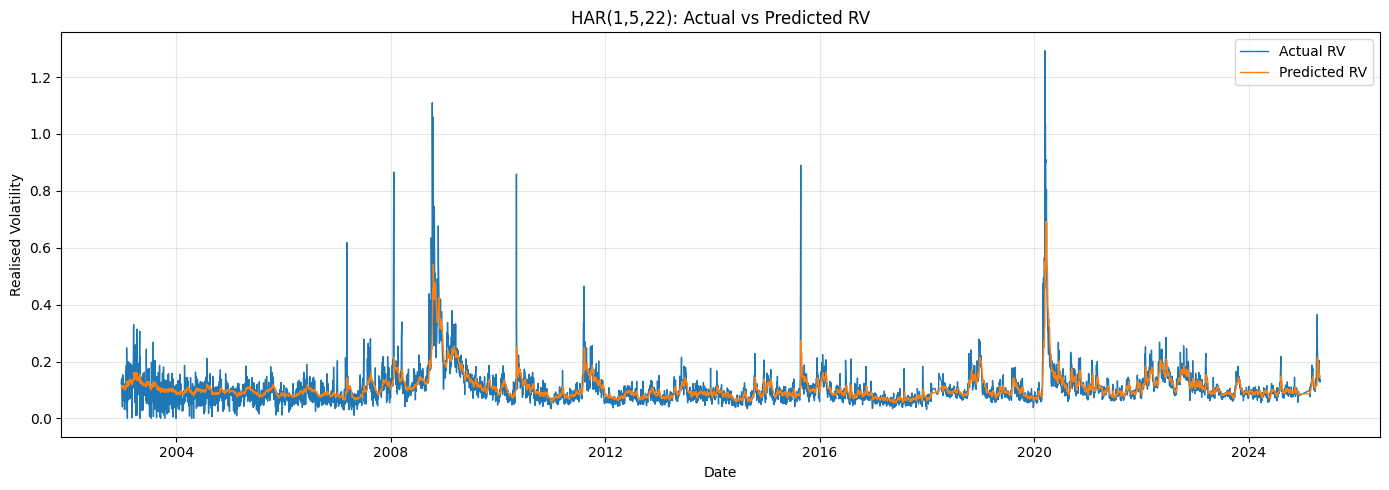

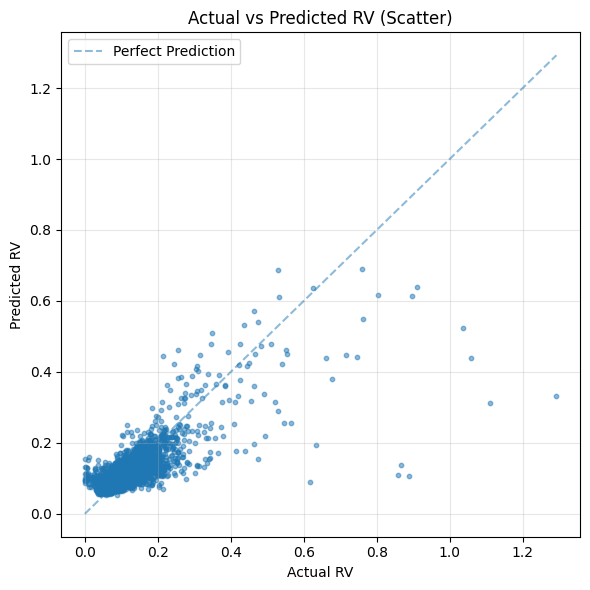

In [80]:
def har_forecast(filepath="XLP.csv"):
    print("="*60); print("HAR Forecast"); print("="*60)

    config = Config()
    Config.use_bic = False

    print("\nLoading data...")
    rv_data = load_and_prepare_data(filepath)

    mode = "HAR(1,5,22)"
    print(f"\nRunning expanding-window {mode} forecasting ...")
    results_df = expanding_window_forecast_HAR(rv_data, config)

    print_summary_statistics(results_df)
    print("\nGenerating plots...")
    plot_results(results_df)

    #return results_df  # return for programmatic use

har_forecast()


HAR Forecast

Loading data...
Data loaded: 6486 observations
Date range: 1998-12-22 to 2025-04-29

Running expanding-window HAR-BIC forecasting ...

SUMMARY STATISTICS

Overall Out-of-Sample Performance:
MSE: 0.002047
QLIKE: 0.056557

Average Performance Across Windows:
In-Sample - MSE: 0.004906, QLIKE: 0.199140
Out-of-Sample - MSE: 0.002024, QLIKE: 0.056380

Correlation between Actual and Predicted: 0.7739

Total number of expanding windows: 259
Total predictions made: 5501

Generating plots...


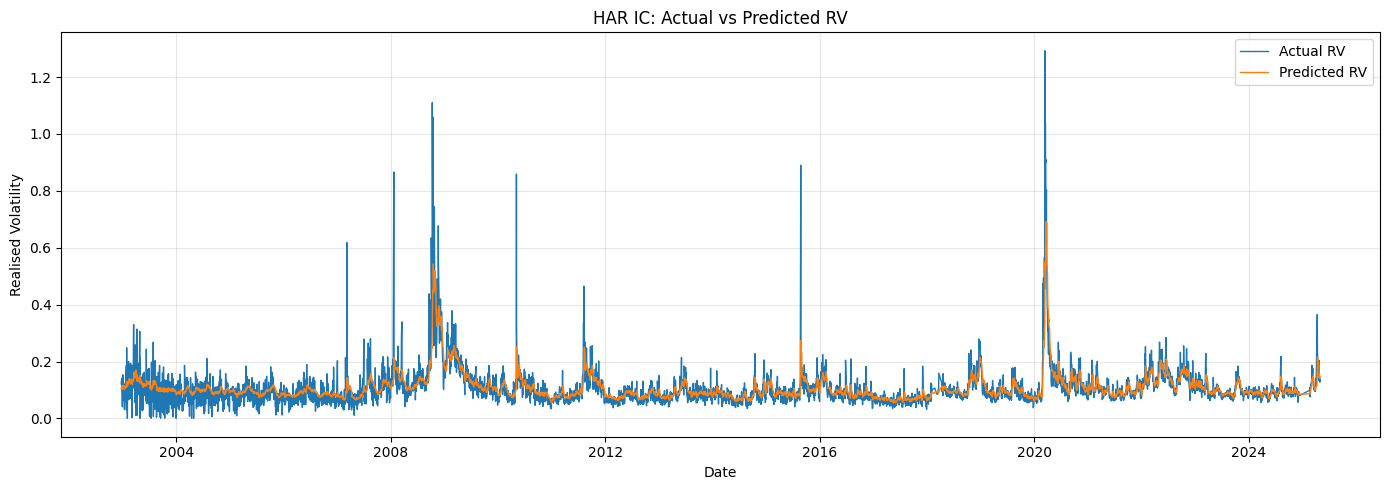

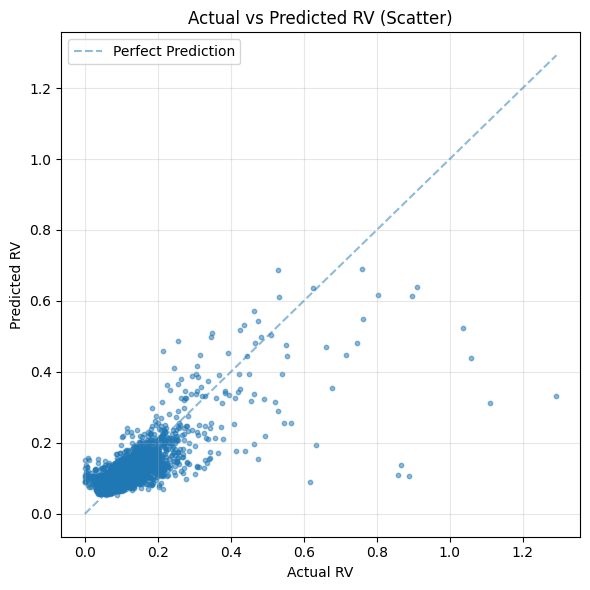

In [81]:
def har_forecast(filepath="XLP.csv"):
    print("="*60); print("HAR Forecast"); print("="*60)

    config = Config()
    Config.use_bic = True

    print("\nLoading data...")
    rv_data = load_and_prepare_data(filepath)

    mode = "HAR-BIC"
    print(f"\nRunning expanding-window {mode} forecasting ...")
    results_df = expanding_window_forecast_HAR(rv_data, config)

    print_summary_statistics(results_df)
    print("\nGenerating plots...")
    plot_results(results_df)

    #return results_df

har_forecast()
